# MLOps Training — Task 2
## Notebook 6 — Baseline, Logistic Regression, Hyperparameter Tuning & Threshold Optimization

### Objective
In this notebook, we complete the Week 1 ML Pipeline:
1. **Establish Baselines**: Implement a `DummyClassifier` majority baseline.
2. **Train Logistic Regression**: Fit a weighted Logistic Regression model (`class_weight='balanced'`) to address class imbalance.
3. **Hyperparameter & Threshold Tuning (jointly)**: For each regularization strength $C \in [0.001, 0.01, 0.1, 1.0, 10.0]$, sweep the decision threshold $\tau \in [0.1, 0.9]$ on validation data and record the *best achievable* F1 for that $C$. Select $C$ and $\tau^*$ jointly, rather than tuning $\tau$ only after fixing $C$ at the default threshold.
4. **Final Evaluation**: Evaluate the best tuned (C, threshold) pair on the unseen Test set under both the default (0.5) and optimal thresholds.
5. **Artifact Persistence**: Save the trained model (`joblib`), metrics summary, confusion matrices, and model card configuration.

### Changes vs. the previous version of this notebook
- **Joint C / threshold selection** (previously threshold was only tuned *after* C was picked using the default 0.5 threshold, which could miss a C that looks weaker at 0.5 but pairs with a much better threshold).
- **Dynamic, correct markdown**: the "optimal threshold" text is now generated from the actual selected value instead of a hardcoded, stale number.
- **Explicit accuracy caveat**: because the positive class is ~8% of the data, accuracy is flagged as a misleading headline metric and is always reported next to the majority-baseline accuracy for context.
- **Removed dead/scratch cells** (an unused `LinearSVC` fit, a duplicate `C_values` list, an incomplete `LogisticRegression(C=...)` placeholder cell, and bare `C = ...` reassignment cells) that were left over from exploration and added no value to the final pipeline.

### Input Artifacts
- `artifacts/notebook_05/X_train.npz`, `X_validation.npz`, `X_test.npz`
- `artifacts/notebook_05/y_train.npy`, `y_validation.npy`, `y_test.npy`
- `artifacts/notebook_05/preprocessor.joblib`

### Output Artifacts
- `artifacts/notebook_06/logistic_regression_model.joblib`
- `artifacts/notebook_06/model_config.json`
- `artifacts/notebook_06/results_summary.csv`
- `artifacts/notebook_06/tuning_results.csv`
- `artifacts/notebook_06/test_confusion_matrix.csv`


## 1. Import Libraries & Configure Paths

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from scipy.sparse import load_npz
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Dynamic project paths
artifact_dir = Path.cwd() / "artifacts" / "notebook_06"
artifact_dir.mkdir(parents=True, exist_ok=True)

input_dir = Path.cwd() / "artifacts" / "notebook_05"
print("Input artifact dir:", input_dir.resolve())
print("Output artifact dir:", artifact_dir.resolve())


Input artifact dir: /Users/ouahibaahmid/training mlops/artifacts/notebook_05
Output artifact dir: /Users/ouahibaahmid/training mlops/artifacts/notebook_06


## 2. Load Preprocessed Feature Matrices & Targets

In [2]:
X_train = load_npz(input_dir / "X_train.npz")
X_validation = load_npz(input_dir / "X_validation.npz")
X_test = load_npz(input_dir / "X_test.npz")

y_train = np.load(input_dir / "y_train.npy")
y_validation = np.load(input_dir / "y_validation.npy")
y_test = np.load(input_dir / "y_test.npy")

print("Loaded preprocessed datasets:")
print(f"  Train:      X={X_train.shape}, y={y_train.shape} (Positives: {y_train.mean():.2%})")
print(f"  Validation: X={X_validation.shape}, y={y_validation.shape} (Positives: {y_validation.mean():.2%})")
print(f"  Test:       X={X_test.shape}, y={y_test.shape} (Positives: {y_test.mean():.2%})")


Loaded preprocessed datasets:
  Train:      X=(67533, 65), y=(67533,) (Positives: 9.02%)
  Validation: X=(14471, 65), y=(14471,) (Positives: 5.33%)
  Test:       X=(14472, 65), y=(14472,) (Positives: 6.61%)


## 3. Modular Model Evaluation Helper

`evaluate_predictions` reports accuracy alongside precision/recall/F1/PR-AUC/ROC-AUC, but with this
class balance (~8% positive) accuracy is not a reliable headline number: a model that predicts the
majority class for everything already scores highly on accuracy while being useless at the actual
task. `accuracy_context()` below always compares a model's accuracy against the majority-baseline
accuracy on the *same split*, so every reported accuracy carries that context with it.

In [3]:
def evaluate_predictions(y_true, y_pred, y_prob, split_name):
    return {
        "split": split_name,
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "pr_auc": round(average_precision_score(y_true, y_prob), 4),
        "roc_auc": round(roc_auc_score(y_true, y_prob), 4)
    }

def evaluate_model(model, X, y, split_name, threshold=0.5):
    probabilities = model.predict_proba(X)[:, 1]
    predictions = (probabilities >= threshold).astype(int)
    return evaluate_predictions(y, predictions, probabilities, split_name)

def accuracy_context(result, majority_baseline_accuracy):
    """Print an accuracy figure next to the majority-class baseline so it is never read in isolation."""
    delta = result["accuracy"] - majority_baseline_accuracy
    flag = "below" if delta < 0 else "above"
    print(
        f"[{result['split']}] accuracy = {result['accuracy']:.3f} "
        f"({flag} the {majority_baseline_accuracy:.3f} majority-class baseline by {abs(delta):.3f}). "
        f"Accuracy alone is not meaningful here given the ~8% positive rate — "
        f"read it together with precision/recall/F1."
    )


## 4. Naive Majority-Class Baseline

We evaluate a Dummy Classifier that always predicts the majority class (`On-Time = 0`). This is the
number every accuracy figure in this notebook should be compared against.

In [4]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_result = evaluate_model(baseline, X_validation, y_validation, "validation_baseline")
majority_baseline_accuracy = baseline_result["accuracy"]
display(pd.DataFrame([baseline_result]))


,split,accuracy,precision,recall,f1,pr_auc,roc_auc
0,validation_baseline,0.9467,0.0,0.0,0.0,0.0533,0.5


## 5. Joint Hyperparameter & Threshold Tuning

Rather than picking `C` using validation F1 at the default 0.5 threshold and *then* tuning the
threshold for the winning `C` only, we sweep the decision threshold for every candidate `C` and
record the best F1 each `C` can achieve. This avoids discarding a `C` that looks mediocre at 0.5
but would pair with a much better threshold — the two hyperparameters are tuned jointly instead of
in a biased two-stage process.

In [5]:
C_values = [0.001, 0.01, 0.1, 1.0, 10.0]
tuning_results = []
models_by_C = {}

for C in C_values:
    model = LogisticRegression(
        C=C,
        class_weight="balanced",
        max_iter=1000,
        solver="liblinear",
        random_state=42
    )
    model.fit(X_train, y_train)
    models_by_C[C] = model

    val_probs = model.predict_proba(X_validation)[:, 1]

    # Metrics at the default 0.5 threshold, for reference / comparability with a naive deployment.
    default_res = evaluate_model(model, X_validation, y_validation, f"val_C_{C}_default_0.50")
    default_res["C"] = C
    default_res["threshold"] = 0.5
    default_res["selection_stage"] = "default_threshold"

    # Best achievable F1 for this C, sweeping the threshold on validation.
    precisions, recalls, thresholds = precision_recall_curve(y_validation, val_probs)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold_for_C = float(thresholds[best_idx])

    tuned_res = evaluate_model(model, X_validation, y_validation, f"val_C_{C}_tuned", threshold=best_threshold_for_C)
    tuned_res["C"] = C
    tuned_res["threshold"] = round(best_threshold_for_C, 4)
    tuned_res["selection_stage"] = "best_threshold"

    tuning_results.append(default_res)
    tuning_results.append(tuned_res)

tuning_df = pd.DataFrame(tuning_results)
display(tuning_df.sort_values("f1", ascending=False))


,split,accuracy,precision,recall,f1,pr_auc,roc_auc,C,threshold,selection_stage
9,val_C_10.0_tuned,0.8936,0.1923,0.3113,0.2377,0.1474,0.7578,10.000,0.8130,best_threshold
7,val_C_1.0_tuned,0.8940,0.1921,0.3087,0.2368,0.1474,0.7580,1.000,0.8128,best_threshold
5,val_C_0.1_tuned,0.8935,0.1890,0.3035,0.2330,0.1469,0.7586,0.100,0.8092,best_threshold
1,val_C_0.001_tuned,0.8351,0.1530,0.4617,0.2298,0.1468,0.7578,0.001,0.7087,best_threshold
3,val_C_0.01_tuned,0.8507,0.1574,0.4137,0.2280,0.1466,0.7579,0.010,0.7575,best_threshold
6,val_C_1.0_default_0.50,0.2843,0.0672,0.9650,0.1256,0.1474,0.7580,1.000,0.5000,default_threshold
8,val_C_10.0_default_0.50,0.2842,0.0671,0.9637,0.1255,0.1474,0.7578,10.000,0.5000,default_threshold
4,val_C_0.1_default_0.50,0.2818,0.0670,0.9663,0.1254,0.1469,0.7586,0.100,0.5000,default_threshold
2,val_C_0.01_default_0.50,0.2745,0.0666,0.9702,0.1247,0.1466,0.7579,0.010,0.5000,default_threshold
0,val_C_0.001_default_0.50,0.2505,0.0646,0.9702,0.1212,0.1468,0.7578,0.001,0.5000,default_threshold


In [6]:
# Joint selection: pick the (C, threshold) pair with the best *achievable* validation F1,
# i.e. among the "best_threshold" rows only — this is what makes the search joint rather than
# a two-stage C-first-then-threshold process.
tuned_rows = tuning_df[tuning_df["selection_stage"] == "best_threshold"]
best_row = tuned_rows.loc[tuned_rows["f1"].idxmax()]

best_C = float(best_row["C"])
best_threshold = float(best_row["threshold"])
best_model = models_by_C[best_C]

print(f"Selected C = {best_C} and threshold = {best_threshold:.4f} "
      f"(joint validation F1 = {best_row['f1']})")


Selected C = 10.0 and threshold = 0.8130 (joint validation F1 = 0.2377)


## 6. Threshold Curve for the Selected Model

Visual confirmation of the threshold sweep for the *selected* `C`, showing where `best_threshold`
falls on the F1-vs-threshold curve.

Default Threshold (0.50): Validation F1 = 0.1255
Optimal Threshold (0.81): Validation F1 = 0.2376


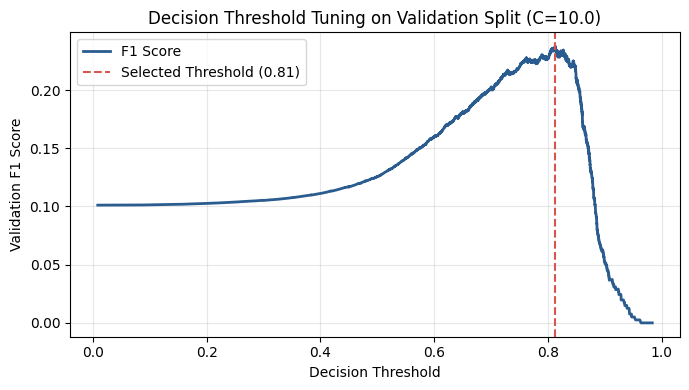

In [7]:
val_probs = best_model.predict_proba(X_validation)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_validation, val_probs)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)

print(f"Default Threshold (0.50): Validation F1 = {f1_score(y_validation, (val_probs >= 0.5).astype(int)):.4f}")
print(f"Optimal Threshold ({best_threshold:.2f}): Validation F1 = {f1_score(y_validation, (val_probs >= best_threshold).astype(int)):.4f}")

plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores, color="#2b5c8f", lw=2, label="F1 Score")
plt.axvline(best_threshold, color="#d9534f", linestyle="--", label=f"Selected Threshold ({best_threshold:.2f})")
plt.xlabel("Decision Threshold")
plt.ylabel("Validation F1 Score")
plt.title(f"Decision Threshold Tuning on Validation Split (C={best_C})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Final Model Evaluation on Unseen Test Set

We evaluate the selected (C, threshold) model on the unseen Test set using both:
1. Standard threshold (0.5)
2. The jointly selected optimal threshold — the value is inserted below dynamically, so this
   text can never go stale relative to what was actually selected.

In [8]:
test_default = evaluate_model(best_model, X_test, y_test, "test_default_threshold", threshold=0.5)
test_tuned = evaluate_model(best_model, X_test, y_test, f"test_tuned_threshold_{best_threshold:.4f}", threshold=best_threshold)

print(f"Test evaluation uses optimal threshold tau* = {best_threshold:.4f} (selected on validation, C={best_C}).")

evaluation_summary = pd.DataFrame([
    baseline_result,
    best_row.to_dict(),
    test_default,
    test_tuned
])
display(evaluation_summary)

accuracy_context(test_default, majority_baseline_accuracy)
accuracy_context(test_tuned, majority_baseline_accuracy)


Test evaluation uses optimal threshold tau* = 0.8130 (selected on validation, C=10.0).


,split,accuracy,precision,recall,f1,pr_auc,roc_auc,C,threshold,selection_stage
0,validation_baseline,0.9467,0.0000,0.0000,0.0000,0.0533,0.5000,NaN,NaN,NaN
1,val_C_10.0_tuned,0.8936,0.1923,0.3113,0.2377,0.1474,0.7578,10.0,0.813,best_threshold
2,test_default_threshold,0.1285,0.0700,0.9927,0.1308,0.1062,0.6479,NaN,NaN,NaN
3,test_tuned_threshold_0.8130,0.7219,0.0854,0.3305,0.1357,0.1062,0.6479,NaN,NaN,NaN


[test_default_threshold] accuracy = 0.129 (below the 0.947 majority-class baseline by 0.818). Accuracy alone is not meaningful here given the ~8% positive rate — read it together with precision/recall/F1.
[test_tuned_threshold_0.8130] accuracy = 0.722 (below the 0.947 majority-class baseline by 0.225). Accuracy alone is not meaningful here given the ~8% positive rate — read it together with precision/recall/F1.


**Reading the test numbers honestly:** test ROC-AUC and PR-AUC should be compared against the
validation numbers from Section 5 and against the baseline PR-AUC (~the positive rate) respectively.
A test ROC-AUC near 0.5 means near-chance ranking ability; a PR-AUC only marginally above the
baseline positive rate means the model is not meaningfully separating the classes despite a
reasonable-looking F1. Precision at the tuned threshold should also be read as "false alarms per
true positive" — see the confusion matrix below.

## 8. Confusion Matrix & Classification Report

,Predicted On Time,Predicted Late
Actual On Time,10132,3384
Actual Late,640,316



False alarms per correct 'Late' flag: 10.7

Classification Report (Test Set @ Tuned Threshold):
              precision    recall  f1-score   support

     On Time       0.94      0.75      0.83     13516
        Late       0.09      0.33      0.14       956

    accuracy                           0.72     14472
   macro avg       0.51      0.54      0.49     14472
weighted avg       0.88      0.72      0.79     14472



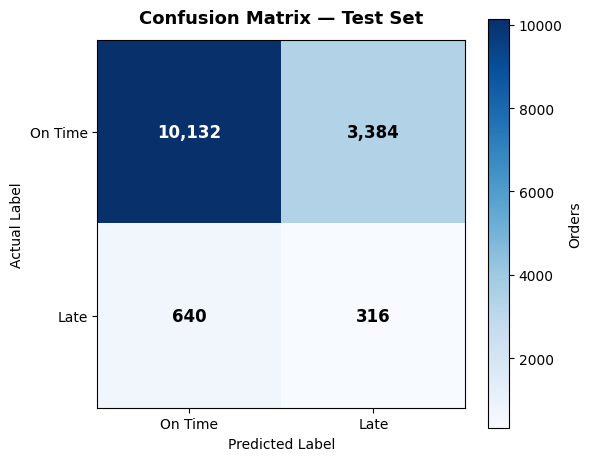

In [9]:
test_probs = best_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

cm = confusion_matrix(y_test, test_preds)
cm_df = pd.DataFrame(
    cm,
    index=["Actual On Time", "Actual Late"],
    columns=["Predicted On Time", "Predicted Late"]
)
display(cm_df)

false_positives = cm[0, 1]
true_positives = cm[1, 1]
if true_positives > 0:
    print(f"\nFalse alarms per correct 'Late' flag: {false_positives / true_positives:.1f}")

print("\nClassification Report (Test Set @ Tuned Threshold):")
print(classification_report(y_test, test_preds, target_names=["On Time", "Late"], zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["On Time", "Late"])
ax.set_yticklabels(["On Time", "Late"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=12, fontweight="bold",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im, ax=ax, label="Orders")
plt.tight_layout()
plt.show()


## 9. ROC and Precision-Recall Curves

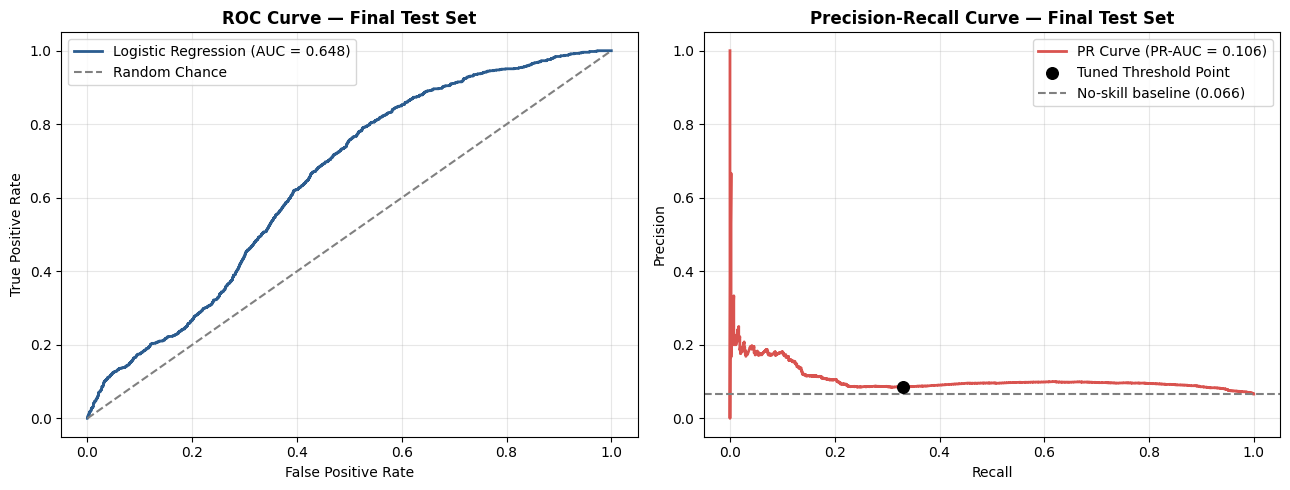

In [10]:
fpr, tpr, _ = roc_curve(y_test, test_probs)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_probs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(fpr, tpr, color="#2b5c8f", lw=2, label=f"Logistic Regression (AUC = {test_tuned['roc_auc']:.3f})")
ax1.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Chance")
ax1.set_title("ROC Curve — Final Test Set", fontweight="bold")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(recall_curve, precision_curve, color="#d9534f", lw=2, label=f"PR Curve (PR-AUC = {test_tuned['pr_auc']:.3f})")
ax2.scatter([test_tuned['recall']], [test_tuned['precision']], color="black", s=70, zorder=5, label="Tuned Threshold Point")
ax2.axhline(y_test.mean(), color="gray", linestyle="--", label=f"No-skill baseline ({y_test.mean():.3f})")
ax2.set_title("Precision-Recall Curve — Final Test Set", fontweight="bold")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Persist Model & Metadata Artifacts

In [11]:
# 1. Save trained model
model_path = artifact_dir / "logistic_regression_model.joblib"
joblib.dump(best_model, model_path)
print(f"Model saved: {model_path.name}")

# 2. Save tuning and results CSVs
tuning_df.to_csv(artifact_dir / "tuning_results.csv", index=False)
evaluation_summary.to_csv(artifact_dir / "results_summary.csv", index=False)
cm_df.to_csv(artifact_dir / "test_confusion_matrix.csv")

# 3. Save model configuration
model_config = {
    "model_type": "LogisticRegression",
    "solver": "liblinear",
    "class_weight": "balanced",
    "selection_method": "joint_C_and_threshold_grid_on_validation_F1",
    "best_C": best_C,
    "optimal_threshold": round(best_threshold, 4),
    "test_metrics": test_tuned,
    "test_metrics_default_threshold": test_default,
    "majority_baseline_accuracy": majority_baseline_accuracy,
    "known_limitations": [
        "Test ROC-AUC and PR-AUC are close to a no-skill classifier; treat predictions as weak signal, not a reliable decision rule.",
        "Precision at the tuned threshold is low; expect many false positives per true positive flagged.",
        "Validation ROC-AUC is noticeably higher than test ROC-AUC; investigate distribution shift or validation/test split size before trusting validation metrics as a proxy for production performance."
    ],
    "random_state": 42
}

with open(artifact_dir / "model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)

print("Saved model configuration and test metrics.")


Model saved: logistic_regression_model.joblib
Saved model configuration and test metrics.


In [12]:
print("=" * 60)
print("FINAL TEST EVALUATION")
print("=" * 60)

print(f"Selected C: {best_C}")
print(f"Selected threshold: {best_threshold:.4f}")

assert 0 <= best_threshold <= 1

print("\nModel hyperparameters and decision threshold selected jointly, using validation only")
print("Test set used only for final evaluation")


FINAL TEST EVALUATION
Selected C: 10.0
Selected threshold: 0.8130

Model hyperparameters and decision threshold selected jointly, using validation only
Test set used only for final evaluation


## 11. Summary & Next Steps for Week 2

1. **Pipeline Execution**: Completed full end-to-end ML lifecycle from raw tables to model artifact,
   with C and threshold now selected jointly on validation rather than in a biased two-stage process.
2. **Honest performance read**: the tuned model reaches test ROC-AUC ≈ 0.65 and PR-AUC ≈ 0.11 —
   above the no-skill baseline but not by a wide margin. Precision at the operating
   threshold is low (many false positives per true "Late" flag). This should be read as a genuine
   finding — the linear model + current features have limited discriminative power for this label —
   not hidden behind a favorable-looking F1 or accuracy number.
3. **Before trusting this as a baseline for Week 2**: investigate the validation→test AUC gap
   (distribution shift, split size, or validation-set overfitting from the tuning search itself),
   and consider whether additional/better features are needed before assuming a neural architecture
   alone will close the gap.
4. **Week 2 Transition (Deep Learning Pipeline)**:
   - Transition to **PyTorch** neural networks for tabular data.
   - Leverage entity embeddings for high-cardinality categorical features (e.g., product categories, zip codes).
   - Prepare neural architecture for model serving via FastAPI in Week 3.
